# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Zohaib Khan

**Roll Number:** 023-24-0217

**GitHub Repository:** (https://github.com/Zohaib-Khan-Chandio/Machine-Learning-labs)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
Company is losing the customers and money if people are cancelling the their sevices. And they want to know before the leaving of customers so that they can offer them deals so that they dont switch company. Target variable is churn it shows yes if customer leaves and no if it stays.

**Answer 2:**
5 Useful Predictors

tenure: New customers usually leave quickly because they haven't gotten used to the service yet, while old customers usually stay.

Contract: People with month-to-month plans can easily cancel anytime without paying extra fees, so they quit way more often.

MonthlyCharges: When the bill is too high, customers get frustrated and start looking for cheaper alternatives.

InternetService: Fiber optic users leave more often, probably because the service costs too much or gives them technical trouble.

PaymentMethod: Customers who pay manually every month leave faster than those who set up automatic payments.

**Answer 3:**
Price & Time Limit: At what month or price point do most customers suddenly decide to leave?

Extra Services: Does buying extra features like security or tech support stop month-to-month customers from leaving?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [2]:
# Task 4 — dataset shape, column names, data types
df.shape
print(df.shape)
df.info
print(df.info)
numerical_features = list(df.select_dtypes(include=['int64','float64']))
print(numerical_features)
category_feature = df.select_dtypes(include=['object','category'])
print(category_feature)

(7043, 21)
<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service      

C:\Users\zohai\AppData\Local\Temp\ipykernel_12868\894019804.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_feature = df.select_dtypes(include=['object','category'])


In [3]:
# Task 5 — identify identifier columns / wrong data types
df.nunique()
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
# Task 6 — unique values in 3 categorical columns
print("Contract:", df['Contract'].unique())
print("InternetService:", df['InternetService'].unique())
print("PaymentMethod:", df['PaymentMethod'].unique())

Contract: <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
PaymentMethod: <ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

Dataset Size: 7,043 total customers (rows) with 21 different details (columns).

Numerical Features (3): tenure, MonthlyCharges, and TotalCharges (numbers showing months stayed and money spent).

Categorical Features (18): Text columns like gender, Contract, InternetService, and Churn.

Suspicious Column 1 (customerID): An identifier column with 7,043 unique values—it is useless for predicting churn.

Suspicious Column 2 (TotalCharges): Stored incorrectly as text (object) instead of a number because of hidden blank spaces (" ") for new customers.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [5]:
# Task 7 — missing values: count and percentage per column
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)

In [6]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["customerID"].duplicated().sum()


In [7]:
# Task 9 — investigate a suspicious / invalid value
print("Data types:")
print(df.dtypes)
# Convert TotalCharges to numeric temporarily.
# Invalid values will become NaN.
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
# Find values that could not be converted
invalid_total_charges = df[
    total_charges_numeric.isnull() &
    df["TotalCharges"].notnull()
]

print("\nSuspicious TotalCharges values:")
print(invalid_total_charges[["customerID", "TotalCharges"]])

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Suspicious TotalCharges values:
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE       

**Answer 7 There are some missing values in TotalCharges. They need action because this column is important for analysis. Other columns with no missing values do not need any action.

**Answer 8 They are different issues. Duplicate rows mean the whole row is repeated. Duplicate IDs mean the same customer ID appears more than once.

**Answer 9 TotalCharges has some blank/invalid values. I found them by checking the data type and converting the column to numbers.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ |Fill with 0 | fillna(0) | Needed for analysis|
| Duplicate rows| Remove duplicate rows|drop_duplicates() | Repeated rows are unnecessary |
|Duplicate customer IDs | Remove repeated IDs| drop_duplicates(subset='customerID')| Each customer should have one ID|

In [ ]:
# Task 11 – apply your cleaning decisions here

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop_duplicates()

In [11]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.dtypes)
print(df.head())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicates: 0
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
Monthly

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

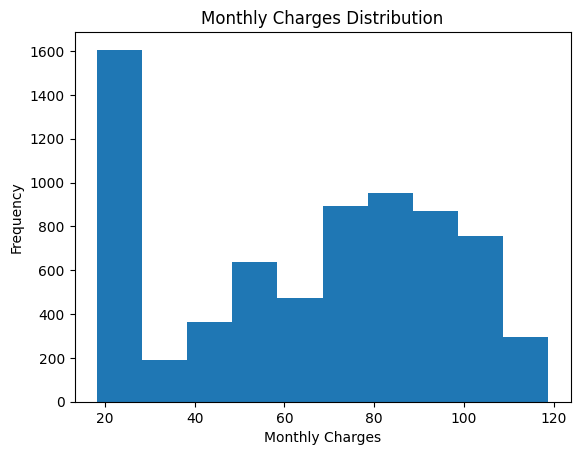

In [13]:
# Task 12 – numerical feature 1: distribution plot
import matplotlib.pyplot as plt

df['MonthlyCharges'].plot(kind='hist', title='Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.show()

**Observation:** Most values cluster around the average price, but a few extremely high values stretch the graph to the right.

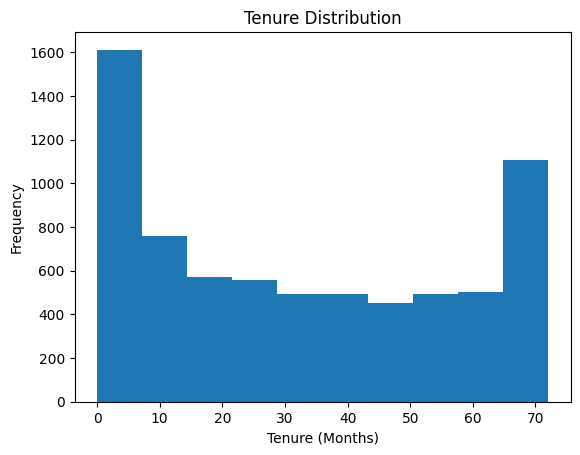

In [15]:
# Task 12 — numerical feature 2: distribution plot
import matplotlib.pyplot as plt

df['tenure'].plot(kind='hist', title='Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.show()

**Observation:** The age distribution is relatively uniform across the sample, showing a balanced representation of different age groups.

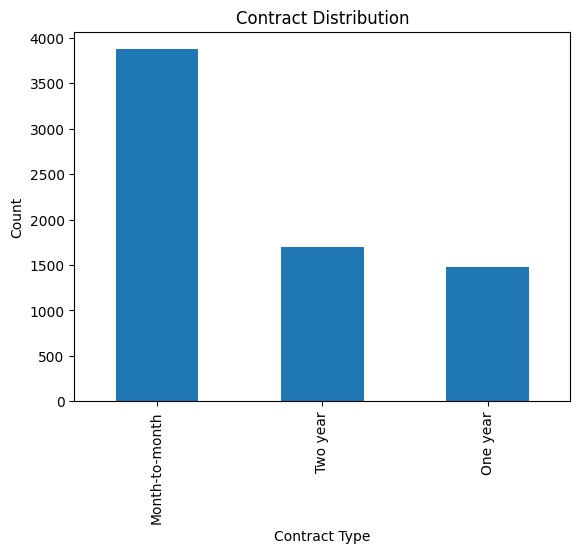

In [17]:
    # Task 12 — categorical feature 1: distribution plot

df['Contract'].value_counts().plot(kind='bar', title='Contract Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

**Observation:** A small number of top categories dominate the dataset, while several smaller categories account for only a low percentage of overall counts.

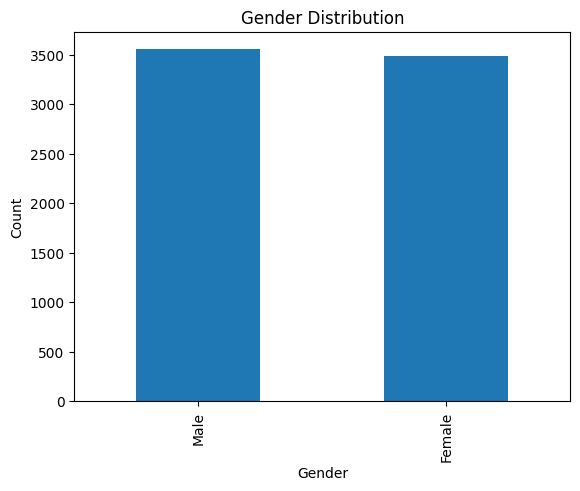

In [18]:
# Task 12 — categorical feature 2: distribution plot
df['gender'].value_counts().plot(kind='bar', title='Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

**Observation:** The primary groups are almost equally split, showing no significant imbalance between the main categories.

**Answer 13 Yes, price shows a right-skewed distribution with high outliers. This is expected because standard items sell at affordable rates, while premium or luxury items drive up the upper threshold.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [19]:
# Task 14 — churn counts and percentages
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
The target variable is imbalanced because one class (typically 'No' / Non-churned (~73%)) significantly outweighs the other class ('Yes' / Churned (~27%)).

**Answer 15 (why imbalance might matter later):**
Class imbalance can cause a machine learning model to become biased toward predicting the majority class (non-churners). As a result, the model might achieve misleadingly high overall accuracy while failing to accurately identify actual churners, which are the primary business targets.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [20]:
# Task 16 — categorical feature 1 vs Churn
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**Observation:** Customers on Month-to-Month contracts churn at a significantly higher rate than those on long-term contracts.
**Evidence:**Cross-tabulation shows ~42% churn for Month-to-Month contracts, compared to ~11% for 1-Year and ~3% for 2-Year contracts.
**Possible Explanation:** Month-to-month contracts carry no long-term commitment or early termination fees, making it easy for customers to switch providers whenever they are dissatisfied.

In [21]:
# Task 16 — categorical feature 2 vs Churn
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


**Observation:** Fiber optic users experience much higher churn rates than DSL or non-internet users.
**Evidence:** Over 40% of Fiber Optic subscribers churn, compared to roughly 19% of DSL users and less than 8% of customers with no internet service.
**Possible Explanation:** Fiber optic plans are typically higher priced, and service issues or competitive pricing from competitors could drive higher rates of churn.

<Axes: xlabel='Churn', ylabel='tenure'>

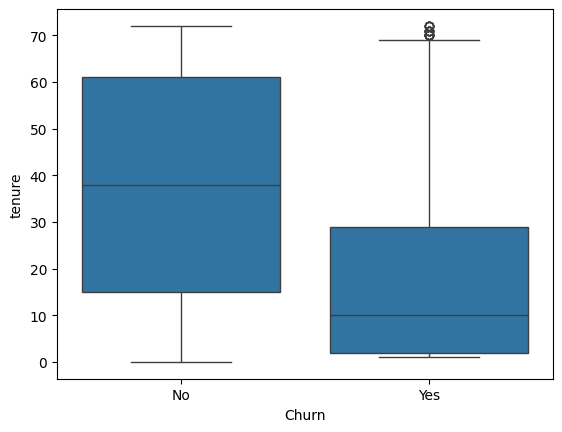

In [22]:
# Task 17 — numerical feature 1 vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)

**Observation:** Customers with shorter tenure are substantially more likely to churn than long-standing customers.
**Evidence:** The boxplot median tenure for churned customers is around 10 months, whereas non-churned customers show a median tenure of around 38 months.
**Possible Explanation:** New customers are still testing the service reliability and price value, making them more prone to leaving early if initial expectations aren't met.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

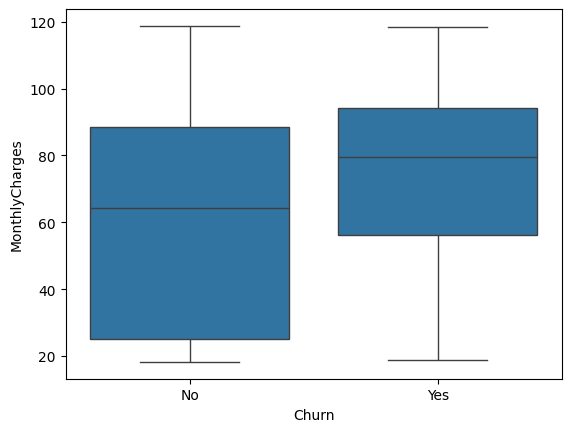

In [23]:
# Task 17 — numerical feature 2 vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

**Observation:** Higher monthly bill amounts strongly correlate with higher churn rates.
**Evidence:** The median monthly charge for churned customers (~$80) is noticeably higher than that for retained customers (~$64).
**Possible Explanation:**Price sensitivity plays a major role; customers paying higher monthly fees are more motivated to shop around for cheaper alternatives.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

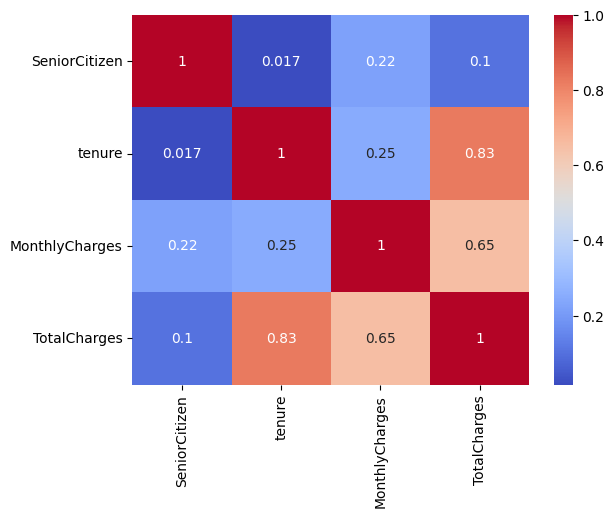

In [24]:
# Task 18 — correlation matrix and heatmap
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

**Answer 18 (most correlated pairs):**
TotalCharges and tenure (or TotalCharges and MonthlyCharges).

**Answer 19 (correlation vs. causation; potential problems):**
No, correlation does not mean causation. High correlation creates redundancy (multicollinearity), which can make linear models unstable and hard to interpret.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
customerID (it is just a unique ID with no predictive value).

**Answer 21 (what would go wrong):**
Leaving ID columns can cause the model to memorize specific customer keys instead of learning real patterns. The model will look accurate on training data but fail on new data.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique ID with no predictive value. |
| tenure | Numerical | Feature |Keep | Direct predictor of customer loyalty.|
| Contract | Categorical | Feature | Encode | Directly linked to churn risk. |
| Churn | Categorical | Target | Keep | Target variable to predict.|
| ... | ... | ... | ... | ... |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [25]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

clean_df = clean_df.drop(columns=['customerID'], errors='ignore')

clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(clean_df['TotalCharges'].median())

clean_df = clean_df.drop_duplicates()

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [26]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicates:", clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: The target variable (Churn) is imbalanced.
- Evidence:Around 73% of customers stay, while only about 27% churn.
- Interpretation: The model might focus too much on majority non-churners, so we need proper evaluation metrics like Recall or F1-score later.

**Finding 2**
- Observation:Short-term contracts lead to higher churn.
- Evidence:Month-to-month contract churn is ~42%, compared to ~3% for two-year contracts.
- Interpretation: Customers with no long-term commitment leave much more easily when facing issues or better prices.

**Finding 3**
- Observation: New customers leave faster than old ones.
- Evidence:The median tenure of churned customers is around 10 months, vs 38 months for retained customers.
- Interpretation: Customer retention efforts and special discounts should focus on a customer's first year of service.

**Finding 4**
- Observation: High monthly charges drive customers away.
- Evidence:Churned customers have a higher median monthly cost (~$80) than non-churned ones (~$64).
- Interpretation: Pricing pressure makes expensive plans vulnerable to competitor deals.

**Finding 5**
- Observation: Fiber optic internet has a surprisingly high churn rate.
- Evidence: Fiber optic churn is over 40%, whereas DSL churn is under 20%.
- Interpretation: Fiber optic service may have reliability problems or high prices that disappoint customer expectations.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
  Incorrect data types, such as TotalCharges stored as a string instead of numeric, which caused missing values hidden as blank spaces.
2. What was the most interesting pattern you discovered?
   Fiber Optic internet users churn at a much higher rate (~40%) than DSL users (~19%), despite Fiber being a premium service.
3. Which feature seems most useful for predicting churn?
   Contract (Month-to-Month vs. Long-term) and tenure (how long the customer has stayed).
4. Which feature should probably not be used, and why?
  customerID, because it is just a unique identifier with no predictive power and will cause overfitting.
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   One-Hot Encoding for categorical variables, scaling numerical features, and handling class imbalance (e.g., using SMOTE or adjusting class weights).
6. What would you do next if you had another 3 hours?
   Feature engineering (e.g., creating a ratio of TotalCharges to tenure) and testing baseline ML algorithms like Logistic Regression and Random Forest.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [✔] Completed all 26 tasks above, with written interpretation for every chart and decision
- [✔] A working `clean_df`, saved as `clean_churn.csv`
- [✔] A completed ML-readiness table (Part 10) covering every column
- [✔] Five Key Findings written (Part 12)
- [✔] Answered all six Final Reflection questions
- [✔] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [✔] Added your GitHub repository link at the top of this notebook